In [49]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

# 🎯 Purporse project

* ### 1. Add Dataframe (df) features to ensure the LLM prompting is relevant to dataframe

* ### 2. Integration PDF report to dataframe for as reliable chatbot

* ### 3. Match recommendation system toward the images for where the product will be shown in UI as ranking recommendation

* ### 4. Merge LSTM model for sales and profit_status prediction (Optional)

* ### 5. Build chatbot experiment integration

## Load images dataset

In [50]:
from PIL import Image

IMAGE_DIR = "../../../fashion_images/dataset_clean"

images = []
image_paths = []

# iterate to call images data
for root, _, files in os.walk(IMAGE_DIR):
    for filename in files:
        if filename.lower().endswith(".jpg"):
            path = os.path.join(root, filename)
            image = Image.open(path).convert("RGB")
            images.append(image)
            image_paths.append(path)
    
print(f"Loaded {len(images)} JPG Images")

Loaded 8625 JPG Images


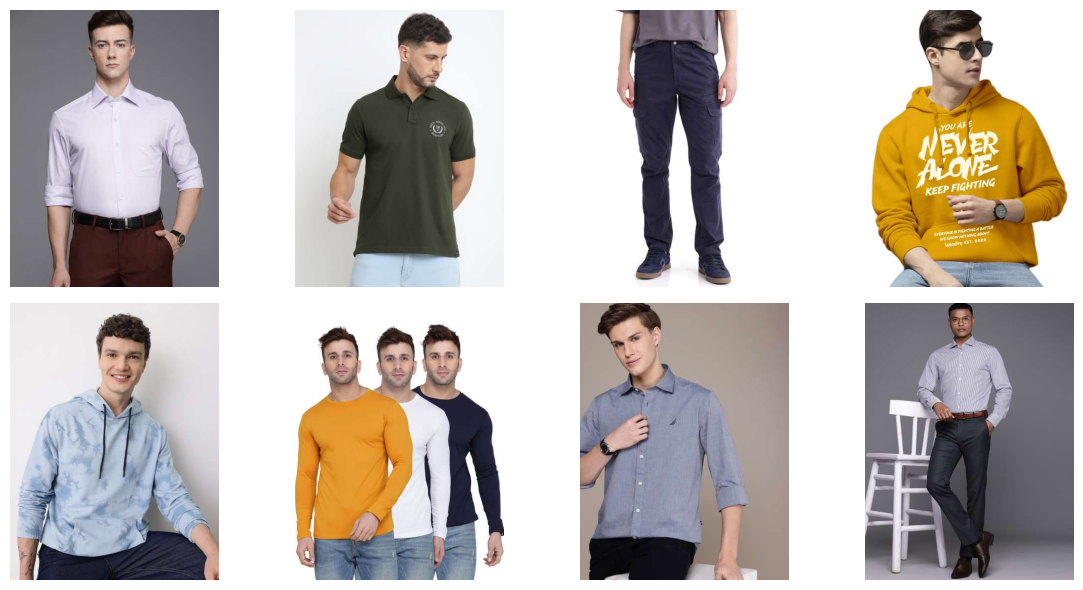

In [51]:
# Show random images

import random
import matplotlib.pyplot as plt

def show_random_images(images, n=8, cols=4, figsize=(12, 6)):
    n = min(n, len(images))
    selected = random.sample(images, n)

    rows = (n + cols - 1) // cols
    plt.figure(figsize=figsize)

    for i, img in enumerate(selected):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# Usage
show_random_images(images, n=8)

## Load dataset

In [52]:
# Load parquet images dataset
df_images = pd.read_parquet("../../../data/matched_fashion_dataset.parquet")

# Load dataframes
df = pd.read_parquet("../../../MLOps/database/data/raw/matched_fashion_balance_rows_prediction.parquet")

## Feature engineering dataframes

* ### Define dir images for ensure the images is exists
* ### Attached df_images -> df (dataframe merged conceptual)

In [53]:
image_dir = "../../../fashion_images/dataset_clean"
from pathlib import Path

# Load data but don't as list
image_list = Path(image_dir).rglob("*.jpg")
image_list = list(image_list)  # Convert generator to list for indexing
image_list[:5]

[PosixPath('../../../fashion_images/dataset_clean/formal_shirts/img_0969.jpg'),
 PosixPath('../../../fashion_images/dataset_clean/formal_shirts/img_0955.jpg'),
 PosixPath('../../../fashion_images/dataset_clean/formal_shirts/img_0799.jpg'),
 PosixPath('../../../fashion_images/dataset_clean/formal_shirts/img_0941.jpg'),
 PosixPath('../../../fashion_images/dataset_clean/formal_shirts/img_0772.jpg')]

In [54]:
image_paths_label = [
    {
       "image_path" : str(p).replace("../../../", ""),
        "filename"   : p.name,
        "category"   : p.parent.name
    }
    for p in image_list
]

image_paths_label[:5]

[{'image_path': 'fashion_images/dataset_clean/formal_shirts/img_0969.jpg',
  'filename': 'img_0969.jpg',
  'category': 'formal_shirts'},
 {'image_path': 'fashion_images/dataset_clean/formal_shirts/img_0955.jpg',
  'filename': 'img_0955.jpg',
  'category': 'formal_shirts'},
 {'image_path': 'fashion_images/dataset_clean/formal_shirts/img_0799.jpg',
  'filename': 'img_0799.jpg',
  'category': 'formal_shirts'},
 {'image_path': 'fashion_images/dataset_clean/formal_shirts/img_0941.jpg',
  'filename': 'img_0941.jpg',
  'category': 'formal_shirts'},
 {'image_path': 'fashion_images/dataset_clean/formal_shirts/img_0772.jpg',
  'filename': 'img_0772.jpg',
  'category': 'formal_shirts'}]

In [55]:
from pathlib import Path

# Define images_path based on category folders in image_paths

for item in image_paths[:10]:
    item_fashion = str(Path(item).name)
    item_class = str(Path(item).parent.name)
    print(item_fashion, item_class)

img_0969.jpg formal_shirts
img_0955.jpg formal_shirts
img_0799.jpg formal_shirts
img_0941.jpg formal_shirts
img_0772.jpg formal_shirts
img_0014.jpg formal_shirts
img_0766.jpg formal_shirts
img_0996.jpg formal_shirts
img_0028.jpg formal_shirts
img_0982.jpg formal_shirts


In [56]:
df_images

,item_id,category,subcategory,sleeve_type,season,fabric,occasion,formality_level,size_range,brand,view_count,click_count,purchase_count,length_cm,price,stocks,item_id_str,idx_within_subcat,image_path
0,TNC_000001,bottoms,men_cargos,long,winter,polyester,casual,high,S,Tommy Hilfiger,93,192,4,97,262476,35,TNC_000001,0,../fashion_images/dataset_clean/men_cargos/img...
1,TNC_000002,tops,formal_shirts,long,winter,linen,party,medium,S,HnM,2941,84,5,77,266987,182,TNC_000002,0,../fashion_images/dataset_clean/formal_shirts/...
2,TNC_000003,tops,formal_shirts,long,winter,denim,party,high,XL,HnM,401,434,35,71,286065,32,TNC_000003,1,../fashion_images/dataset_clean/formal_shirts/...
3,TNC_000004,tops,printed_tshirts,short,all-season,linen,office,low,XXL,Tommy Hilfiger,318,85,101,70,153376,149,TNC_000004,0,../fashion_images/dataset_clean/printed_tshirt...
4,TNC_000005,tops,formal_shirts,long,all-season,polyester,casual,low,L,ZARA,857,153,67,69,323155,43,TNC_000005,2,../fashion_images/dataset_clean/formal_shirts/...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1099995,TNC_1099996,tops,solid_tshirts,short,summer,polyester,party,medium,M,HnM,2924,183,2,73,140786,163,TNC_1099996,109772,../fashion_images/dataset_clean/solid_tshirts/...
1099996,TNC_1099997,bottoms,formal_pants,long,summer,denim,party,high,XXL,Polo,2362,94,32,95,353863,198,TNC_1099997,183895,../fashion_images/dataset_clean/formal_pants/i...
1099997,TNC_1099998,bottoms,men_cargos,long,winter,fleece,casual,low,M,Adidas,617,147,39,97,299627,78,TNC_1099998,183289,../fashion_images/dataset_clean/men_cargos/img...
1099998,TNC_1099999,tops,solid_tshirts,short,summer,cotton,office,low,XXL,Tommy Hilfiger,326,0,25,71,153123,172,TNC_1099999,109773,../fashion_images/dataset_clean/solid_tshirts/...


In [57]:
image_paths_df_images = df_images['image_path'].iloc[:len(df)].reset_index(drop=True) # Define image_paths here before attaching to df
subcategory_paths_df_images = df_images['subcategory'].iloc[:len(df)].reset_index(drop=True) # Define subcategory_paths here before attaching to df
category_paths_df_images = df_images['category'].iloc[:len(df)].reset_index(drop=True) # Define category_paths here before attaching to df
brand_paths_df_images = df_images['brand'].iloc[:len(df)].reset_index(drop=True) # Define brand_paths here before attaching to df
occasion_paths_df_images = df_images['occasion'].iloc[:len(df)].reset_index(drop=True) # Define occasion_paths here before attaching to df
size_range_paths_df_images = df_images['size_range'].iloc[:len(df)].reset_index(drop=True) # Define size_range_paths here before attaching to df

# Attach to df
df_merged = df.copy()
df_merged['image_path'] = image_paths_df_images
df_merged['subcategory'] = subcategory_paths_df_images
df_merged['category'] = category_paths_df_images
df_merged['brand'] = brand_paths_df_images
df_merged['occasion'] = occasion_paths_df_images
df_merged['size_range'] = size_range_paths_df_images

print(f"Merged shape:         {df_merged.shape}")          # 298,150
print(f"Missing image_path:   {df_merged['image_path'].isna().sum()}")  # should be 0
print(df_merged[['item_id', 'image_path']].head())

Merged shape:         (298150, 19)
Missing image_path:   0
       item_id                                         image_path
0  item_000001  ../fashion_images/dataset_clean/men_cargos/img...
1  item_000001  ../fashion_images/dataset_clean/formal_shirts/...
2  item_000001  ../fashion_images/dataset_clean/formal_shirts/...
3  item_000001  ../fashion_images/dataset_clean/printed_tshirt...
4  item_000001  ../fashion_images/dataset_clean/formal_shirts/...


In [58]:
# Fix paths for diplay on df_merged
df_merged['image_path'] = list(df_merged['image_path'].apply(lambda x: str(x).replace("../", "../../../")))
df_merged.head()

,item_id,date,purchase_count,view_count,price,stocks,sales,stock_value_retail,profit_status,conversion_rate,sales_log,predicted_sales,predicted_profit,image_path,subcategory,category,brand,occasion,size_range
0,item_000001,2025-01-31,3.0,3736.0,346555.0,172.0,30383339.0,49100152.0,1.0,60.195342,17.229404,127866.250000,profit,../../../fashion_images/dataset_clean/men_carg...,men_cargos,bottoms,Tommy Hilfiger,casual,S
1,item_000001,2025-02-01,3.0,356.0,216545.0,96.0,24742335.0,25600992.0,1.0,70.376131,17.024027,56849.851562,profit,../../../fashion_images/dataset_clean/formal_s...,formal_shirts,tops,HnM,party,S
2,item_000001,2025-02-02,0.0,0.0,216545.0,96.0,0.0,25600992.0,1.0,0.000000,0.000000,104502.617188,profit,../../../fashion_images/dataset_clean/formal_s...,formal_shirts,tops,HnM,party,XL
3,item_000001,2025-02-03,2.0,1044.0,284314.0,49.0,17303367.0,14108619.0,1.0,6.638782,16.666412,32212.800781,profit,../../../fashion_images/dataset_clean/printed_...,printed_tshirts,tops,Tommy Hilfiger,office,XXL
4,item_000001,2025-02-04,2.0,1104.0,285865.0,148.0,18683496.0,41282232.0,1.0,6.484313,16.743151,75313.539062,profit,../../../fashion_images/dataset_clean/formal_s...,formal_shirts,tops,ZARA,casual,L


In [59]:
image_paths[:10]

['../../../fashion_images/dataset_clean/formal_shirts/img_0969.jpg',
 '../../../fashion_images/dataset_clean/formal_shirts/img_0955.jpg',
 '../../../fashion_images/dataset_clean/formal_shirts/img_0799.jpg',
 '../../../fashion_images/dataset_clean/formal_shirts/img_0941.jpg',
 '../../../fashion_images/dataset_clean/formal_shirts/img_0772.jpg',
 '../../../fashion_images/dataset_clean/formal_shirts/img_0014.jpg',
 '../../../fashion_images/dataset_clean/formal_shirts/img_0766.jpg',
 '../../../fashion_images/dataset_clean/formal_shirts/img_0996.jpg',
 '../../../fashion_images/dataset_clean/formal_shirts/img_0028.jpg',
 '../../../fashion_images/dataset_clean/formal_shirts/img_0982.jpg']

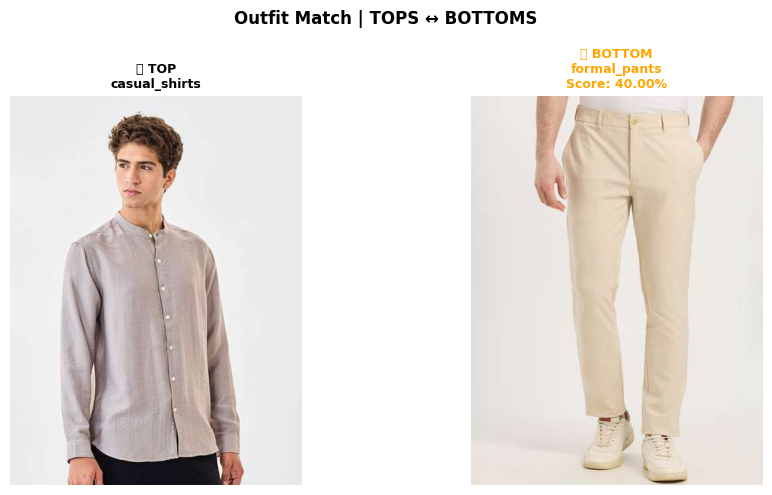

Input    : ../../../fashion_images/dataset_clean/casual_shirts/img_1221.jpg
Matched  : ../../../fashion_images/dataset_clean/formal_pants/img_0969.jpg
Score    : 40.00%


In [60]:
from difflib import SequenceMatcher
import os
import random

# Buikd fast lookup: filename -> (Category, Subcategory, Full Path)
lookup = {
    Path(str(r['image_path'])).name: r for _, r in df_merged.drop_duplicates(subset=['image_path']).iterrows()
}

def match_outfit(image_path, df_merged):
    input_name = Path(str(image_path)).name
    input_row = lookup.get(input_name)

    if input_row is None:
        print(f"Image {input_name} not found in dataset.")

    input_category = str(input_row['category']).lower()
    input_subcategory = str(input_row['subcategory']).lower()
    target_category = 'bottoms' if input_category == 'tops' else 'tops'

    # Filter opposite category & score
    df_opp = df_merged[df_merged['category'].str.lower() == target_category]
    df_opp = df_opp.assign(score=df_opp['subcategory'].apply(
        lambda s: SequenceMatcher(None, input_subcategory, str(s).lower()).ratio()
    ))
    best = df_opp.loc[df_opp['score'].idxmax()]
    percentage = best['score'] * 100

    # Display
    color = 'green' if percentage > 70 else 'orange' if percentage >= 40 else 'red'
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(Image.open(image_path));         axes[0].axis('off')
    axes[0].set_title(f"{'👕 TOP' if input_category=='tops' else '👖 BOTTOM'}\n{input_subcategory}", fontsize=9, fontweight='bold')
    axes[1].imshow(Image.open(best['image_path'])); axes[1].axis('off')
    axes[1].set_title(f"{'👖 BOTTOM' if input_category=='tops' else '👕 TOP'}\n{best['subcategory']}\nScore: {percentage:.2f}%", fontsize=9, color=color, fontweight='bold')
    plt.suptitle(f"Outfit Match | {input_category.upper()} ↔ {target_category.upper()}", fontweight='bold')
    plt.tight_layout(); plt.show()

    return best, best['score']

# Example usage
PATH_IMAGES = Path("../../../fashion_images/dataset_clean")
test_image_path = str(random.choice(list(PATH_IMAGES.rglob("*.jpg"))))

best, score = match_outfit(test_image_path, df_merged)
print(f"Input    : {test_image_path}")
print(f"Matched  : {best['image_path']}")
print(f"Score    : {score * 100:.2f}%")

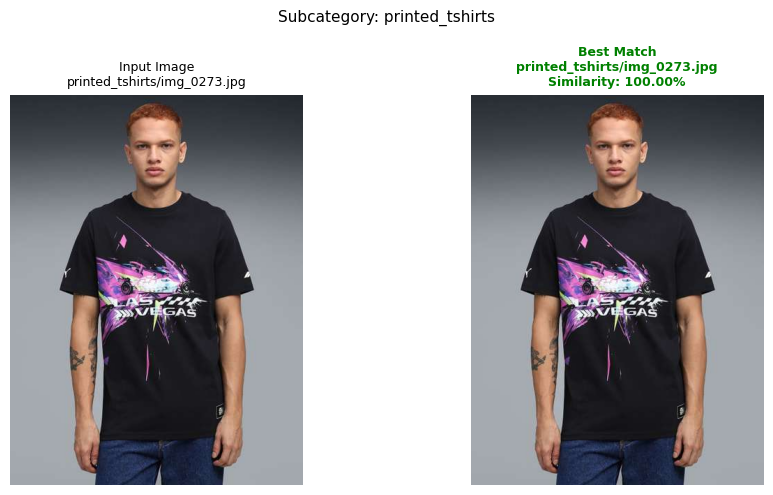

Input      : ../../../fashion_images/dataset_clean/printed_tshirts/img_0273.jpg
Best match : ../../../fashion_images/dataset_clean/printed_tshirts/img_0273.jpg
Subcategory: printed_tshirts
Similarity : 100.00%


In [61]:
from difflib import SequenceMatcher
from pathlib import Path
import os, random

def image_path_similarity(image_path, df_merged):
    """Match input image against df_merged using FULL path (folder + filename)"""
    best_match    = None
    highest_ratio = 0

    input_path   = str(image_path)
    input_folder = Path(image_path).parent.name   # e.g. 'formal_shirts'
    input_name   = Path(image_path).name           # e.g. 'img_1169.jpg'

    for _, row in df_merged.iterrows():
        df_path   = str(row['image_path'])
        df_folder = Path(df_path).parent.name      # e.g. 'formal_shirts'
        df_name   = Path(df_path).name             # e.g. 'img_1169.jpg'

        # ── Match: folder (subcategory) + filename BOTH must align ──
        ratio_folder = SequenceMatcher(None, input_folder, df_folder).ratio()
        ratio_name   = SequenceMatcher(None, input_name,   df_name).ratio()

        # Weight folder match higher to avoid cross-category false positives
        weighted = (ratio_folder * 0.7) + (ratio_name * 0.3)

        if weighted > highest_ratio:
            highest_ratio = weighted
            best_match    = row

    # ── Display ───────────────────────────────────────────────
    if best_match is not None:
        score = highest_ratio * 100
        color = 'green' if score >= 70 else 'orange' if score >= 40 else 'red'

        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        axes[0].imshow(Image.open(image_path))
        axes[0].set_title(
            f"Input Image\n{input_folder}/{input_name}",
            fontsize=9
        )
        axes[0].axis('off')

        axes[1].imshow(Image.open(best_match['image_path']))
        axes[1].set_title(
            f"Best Match\n{Path(best_match['image_path']).parent.name}/{Path(best_match['image_path']).name}\n"
            f"Similarity: {score:.2f}%",
            fontsize=9, color=color, fontweight='bold'
        )
        axes[1].axis('off')

        plt.suptitle(f"Subcategory: {best_match['subcategory']}", fontsize=11)
        plt.tight_layout()
        plt.show()

    return best_match, highest_ratio


# ── Example usage ─────────────────────────────────────────────
PATH_IMAGES     = Path("../../../fashion_images/dataset_clean")
test_image_path = str(random.choice(list(PATH_IMAGES.rglob("*.jpg"))))

best_match, similarity = image_path_similarity(test_image_path, df_merged)
print(f"Input      : {test_image_path}")
print(f"Best match : {best_match['image_path']}")
print(f"Subcategory: {best_match['subcategory']}")
print(f"Similarity : {similarity * 100:.2f}%")

## Top recommendation for matching outfit

Input: ../../../fashion_images/dataset_clean/casual_shirts/img_0557.jpg



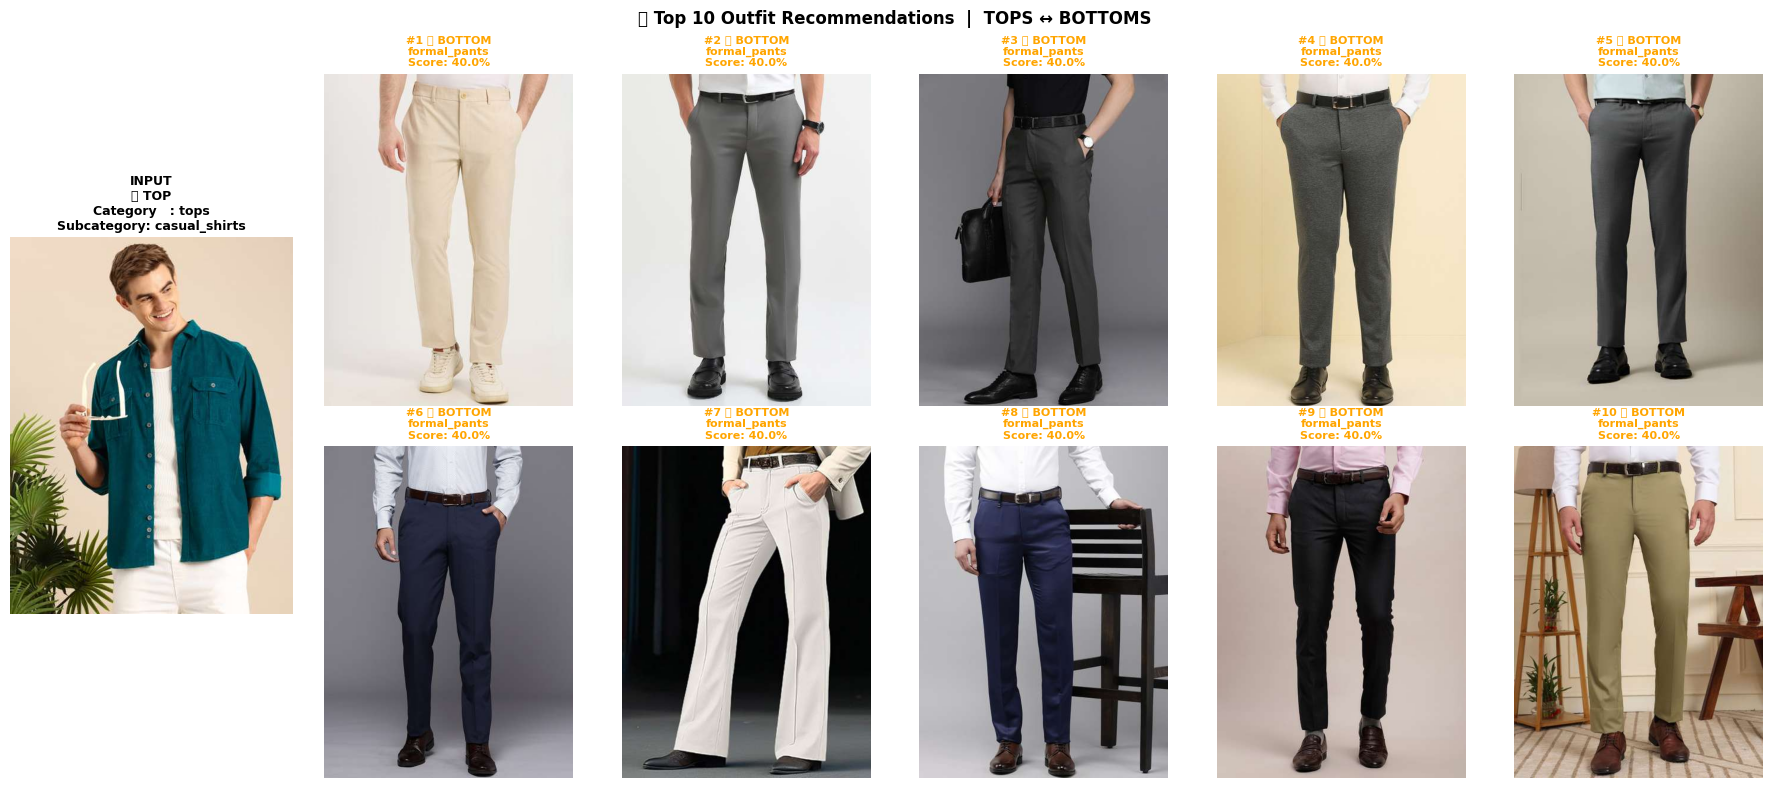


Input       : img_0557.jpg
Category    : tops  →  Recommending: bottoms
Subcategory : casual_shirts
#1  formal_pants              Score: 40.0%  |  img_0969.jpg
#2  formal_pants              Score: 40.0%  |  img_0955.jpg
#3  formal_pants              Score: 40.0%  |  img_0799.jpg
#4  formal_pants              Score: 40.0%  |  img_0941.jpg
#5  formal_pants              Score: 40.0%  |  img_0772.jpg
#6  formal_pants              Score: 40.0%  |  img_0014.jpg
#7  formal_pants              Score: 40.0%  |  img_0766.jpg
#8  formal_pants              Score: 40.0%  |  img_0996.jpg
#9  formal_pants              Score: 40.0%  |  img_0982.jpg
#10 formal_pants              Score: 40.0%  |  img_0570.jpg


In [62]:
from difflib import SequenceMatcher
from pathlib import Path
import random

# ── Build lookup: (folder/filename) → row ────────────────────
lookup = {
    f"{Path(str(r['image_path'])).parent.name}/{Path(str(r['image_path'])).name}": r
    for _, r in df_merged.drop_duplicates('image_path').iterrows()
}

def recommend_outfit(image_path, df_merged, top_n=10):
    image_path = Path(str(image_path))
    input_key  = f"{image_path.parent.name}/{image_path.name}"
    input_row  = lookup.get(input_key)

    if input_row is None:
        print(f"⚠️ Not found in lookup: {input_key}"); return
    if not image_path.exists():
        print(f"⚠️ File not found on disk: {image_path}"); return

    input_cat    = str(input_row['category']).lower()
    input_subcat = str(input_row['subcategory']).lower()
    target_cat   = 'bottoms' if input_cat == 'tops' else 'tops'

    # ── Score opposite category ───────────────────────────────
    df_opp = df_merged[df_merged['category'].str.lower() == target_cat].copy()
    df_opp = df_opp.drop_duplicates('image_path')
    df_opp['score'] = df_opp['subcategory'].apply(
        lambda s: SequenceMatcher(None, input_subcat, str(s).lower()).ratio()
    )
    df_opp  = df_opp[df_opp['image_path'].apply(lambda p: Path(str(p)).exists())]
    top_rec = df_opp.nlargest(top_n, 'score')

    # ── Dynamic grid: 1 input col + ceil(top_n/rows) cols ────
    n_cols  = 6                              # 1 input + 5 recommendations per row
    n_rows  = -(-top_n // (n_cols - 1))     # ceil division  → 2 rows for top_n=10
    fig     = plt.figure(figsize=(n_cols * 3, n_rows * 4))

    # ── Input image spans all rows on the left ────────────────
    ax_input = fig.add_subplot(n_rows, n_cols, tuple(
        range(1, n_rows * n_cols, n_cols)   # e.g. [1, 7] for 2 rows
    ) if n_rows > 1 else 1)
    ax_input.imshow(Image.open(image_path))
    ax_input.axis('off')
    ax_input.set_title(
        f"INPUT\n{'👕 TOP' if input_cat == 'tops' else '👖 BOTTOM'}\n"
        f"Category   : {input_cat}\n"
        f"Subcategory: {input_subcat}",
        fontsize=9, fontweight='bold'
    )

    # ── Recommendation positions: skip col 1 every row ───────
    positions = [
        r * n_cols + c
        for r in range(n_rows)
        for c in range(2, n_cols + 1)       # cols 2–6
    ][:top_n]

    for i, (_, row) in enumerate(top_rec.iterrows()):
        pct   = row['score'] * 100
        color = 'green' if pct >= 70 else 'orange' if pct >= 40 else 'red'
        ax    = fig.add_subplot(n_rows, n_cols, positions[i])
        ax.imshow(Image.open(row['image_path']))
        ax.axis('off')
        ax.set_title(
            f"#{i+1} {'👖 BOTTOM' if input_cat == 'tops' else '👕 TOP'}\n"
            f"{row['subcategory']}\nScore: {pct:.1f}%",
            fontsize=8, color=color, fontweight='bold'
        )

    plt.suptitle(
        f"👗 Top {top_n} Outfit Recommendations  |  {input_cat.upper()} ↔ {target_cat.upper()}",
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout(); plt.show()

    # ── Summary ───────────────────────────────────────────────
    print(f"\n{'='*55}")
    print(f"Input       : {image_path.name}")
    print(f"Category    : {input_cat}  →  Recommending: {target_cat}")
    print(f"Subcategory : {input_subcat}")
    print(f"{'='*55}")
    for i, (_, row) in enumerate(top_rec.iterrows()):
        print(f"#{i+1:<2} {row['subcategory']:<25} Score: {row['score']*100:.1f}%  |  {Path(str(row['image_path'])).name}")

    return top_rec


# ── Usage ─────────────────────────────────────────────────────
INPUT_IMAGE = random.choice(list(PATH_IMAGES.rglob("*.jpg")))

print(f"Input: {INPUT_IMAGE}\n")
top_rec = recommend_outfit(INPUT_IMAGE, df_merged, top_n=10)

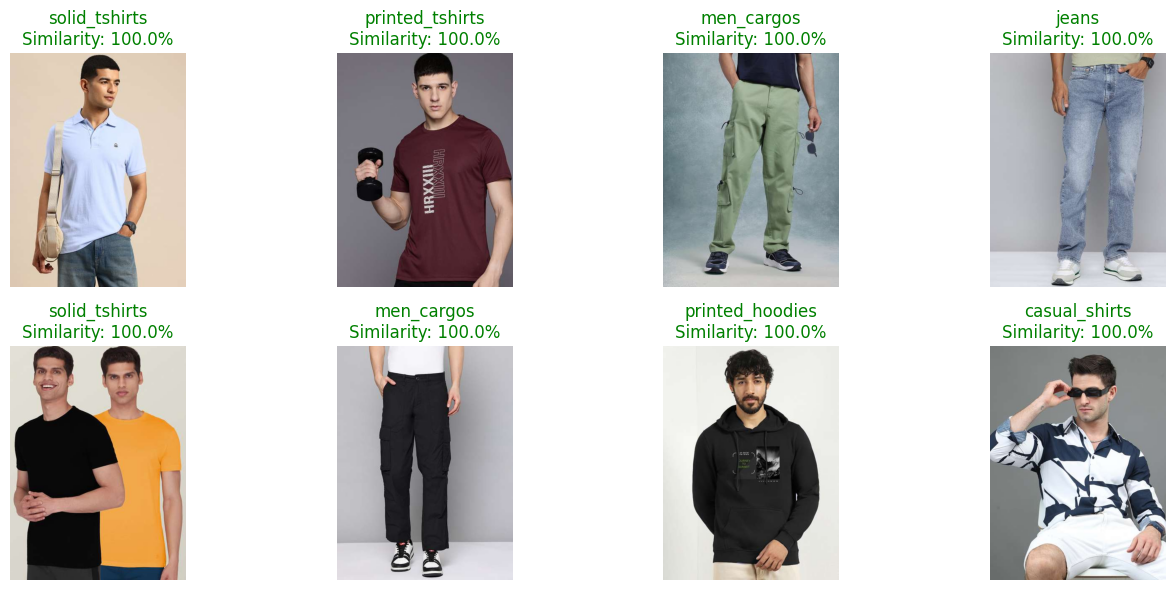

In [63]:
from difflib import SequenceMatcher
from pathlib import Path

# ── Fix: compare folder name vs subcategory (correct logic) ──
df_merged['similarity'] = df_merged.apply(
    lambda row: round(
        SequenceMatcher(None,
            Path(str(row['image_path'])).parent.name,  # ✅ folder = subcategory name
            str(row['subcategory'])                    # ✅ subcategory column
        ).ratio() * 100, 2
    ), axis=1
)

# Show random images from dataframe
def show_random_images_from_df_merged(df_merged, n=8, cols=4, figsize=(14, 6)):
    selected = df_merged.dropna(subset=['image_path']).sample(n)
    rows_grid = (n + cols - 1) // cols

    plt.figure(figsize=figsize)

    for i, (_, row) in enumerate(selected.iterrows()):
        sim   = row['similarity']
        color = 'green' if sim >= 70 else 'orange' if sim >= 40 else 'red'

        plt.subplot(rows_grid, cols, i + 1)
        plt.imshow(Image.open(row['image_path']))
        plt.title(f"{row['subcategory']}\nSimilarity: {sim}%", color=color, fontsize=12)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_random_images_from_df_merged(df_merged, n=8)

## Load repot anaylsis PDF

In [64]:
# ============================================================
# CELL 1 — Install dependencies (run once)
# ============================================================
# !pip install langchain langchain-community pypdf -q


# ============================================================
# CELL 2 — Load PDF with LangChain
# ============================================================
from langchain_community.document_loaders import PyPDFLoader

PDF_DIR = "../../../pipelines/ai_engineer/docs/RAG_Analysis_Report.pdf"
loader = PyPDFLoader(PDF_DIR)
pages = loader.load_and_split()

print(f"✅ Loaded {len(pages)} pages from PDF")


# ============================================================
# CELL 3 — Display as Styled RAG Report UI in Notebook
# ============================================================
from IPython.display import display, HTML
import re
from datetime import datetime

# ── helpers ──────────────────────────────────────────────────

def extract_meta(pages):
    """Pull title, date, subject, preparer from first page text."""
    text = pages[0].page_content if pages else ""
    lines = [l.strip() for l in text.split("\n") if l.strip()]

    # Date
    date_match = re.search(
        r"(January|February|March|April|May|June|July|August|"
        r"September|October|November|December)\s+\d{1,2},?\s+\d{4}", text, re.I
    )
    date = date_match.group(0) if date_match else datetime.today().strftime("%B %d, %Y")

    # Title — longest short line on page 1
    title_candidates = [l for l in lines if 8 < len(l) < 80]
    title = title_candidates[0] if title_candidates else "RAG Analysis Report"

    # Subject — second candidate
    subject = title_candidates[1] if len(title_candidates) > 1 else "Business Intelligence"

    # Prepared by
    prep = re.search(r"Prepared\s+by[:\s]+([^\n]+)", text, re.I)
    prepared_by = prep.group(1).strip() if prep else "Intelligence Team"

    # Classification
    cls = re.search(r"Classification[:\s]+([^\n]+)", text, re.I)
    classification = cls.group(1).strip() if cls else "Confidential — Internal Use Only"

    return dict(title=title, subject=subject, date=date,
                prepared_by=prepared_by, classification=classification)


def build_toc(pages):
    """Extract Q1/Q2 style headings or first line per page for TOC."""
    toc = []
    seen = set()
    for i, page in enumerate(pages):
        for line in page.page_content.split("\n"):
            line = line.strip()
            if re.match(r"^Q\d+[\.\)]", line, re.I) or re.match(r"^\d+[\.\)]\s+[A-Z]", line):
                short = line[:70] + ("..." if len(line) > 70 else "")
                if short not in seen:
                    seen.add(short)
                    toc.append((short, i + 1))
    if not toc:
        for i, page in enumerate(pages[:8]):
            first = next((l.strip() for l in page.page_content.split("\n") if l.strip()), "")
            short = first[:70] + ("..." if len(first) > 70 else "")
            toc.append((short, i + 1))
    return toc[:10]


def render_report(pages):
    """Render full styled RAG Report HTML inside a Jupyter cell."""
    meta   = extract_meta(pages)
    toc    = build_toc(pages)

    # ── TOC rows ──────────────────────────────────────────────
    toc_rows = "".join(
        f'<div class="toc-item">{item}'
        f'<span class="toc-pg">p.{pg}</span></div>'
        for item, pg in toc
    )
    toc_rows += '<div class="toc-item">Appendix A. Results Summary Table</div>'

    # ── Page sections ─────────────────────────────────────────
    page_sections = ""
    for i, page in enumerate(pages):
        safe = (page.page_content
                .replace("&", "&amp;")
                .replace("<", "&lt;")
                .replace(">", "&gt;"))
        page_sections += f"""
        <div class="page-card">
            <div class="page-label">Page {i+1} of {len(pages)}</div>
            <div class="page-text">{safe}</div>
        </div>"""

    # ── Full HTML ─────────────────────────────────────────────
    html = f"""
    <div id="rag-report">
    <style>
        #rag-report {{
            font-family: Arial, sans-serif;
            background: #f0f4f8;
            padding: 0 0 40px 0;
            color: #1a1a2e;
        }}
        #rag-report .top-bar {{
            background: #0d1b3e;
            color: #fff;
            padding: 11px 32px;
            display: flex;
            justify-content: space-between;
            font-size: 13px;
            font-weight: bold;
            letter-spacing: .5px;
            border-bottom: 3px solid #2563eb;
        }}
        #rag-report .wrapper {{
            max-width: 900px;
            margin: 0 auto;
            padding: 36px 20px;
        }}
        #rag-report .hero {{
            background: #0d1b3e;
            border-radius: 8px;
            padding: 50px 48px;
            margin-bottom: 22px;
            text-align: center;
        }}
        #rag-report .hero h1 {{
            color: #fff;
            font-size: 50px;
            font-weight: 900;
            margin: 0;
            letter-spacing: -1px;
        }}
        #rag-report .meta-box {{
            background: linear-gradient(135deg,#2563eb,#3b82f6);
            border-radius: 8px;
            padding: 30px 48px;
            margin-bottom: 30px;
            text-align: center;
            color: #fff;
        }}
        #rag-report .meta-box .meta-title {{
            font-size: 21px;
            font-weight: 600;
            margin-bottom: 10px;
        }}
        #rag-report .meta-box .meta-item {{
            font-size: 14px;
            opacity: .82;
            margin: 3px 0;
        }}
        #rag-report hr.divider {{
            border: none;
            border-top: 2px solid #2563eb;
            margin: 28px 0 22px;
        }}
        #rag-report .section-title {{
            color: #0d1b3e;
            font-size: 19px;
            font-weight: 800;
            margin-bottom: 10px;
        }}
        #rag-report .exec-summary {{
            background: #dbeafe;
            border-radius: 6px;
            padding: 18px 22px;
            font-size: 14.5px;
            line-height: 1.75;
            text-align: justify;
            margin-bottom: 28px;
        }}
        #rag-report .exec-summary strong {{ color: #0d1b3e; }}
        #rag-report .toc-title {{
            color: #2563eb;
            font-size: 19px;
            font-weight: 800;
            margin-bottom: 8px;
        }}
        #rag-report .toc-item {{
            font-size: 13.5px;
            padding: 5px 0;
            border-bottom: 1px solid #e2e8f0;
            color: #1e293b;
        }}
        #rag-report .toc-pg {{
            float: right;
            color: #94a3b8;
            font-size: 12px;
        }}
        #rag-report .page-card {{
            background: #fff;
            border-radius: 8px;
            padding: 24px 28px;
            margin-bottom: 20px;
            box-shadow: 0 2px 8px rgba(0,0,0,.07);
            border-left: 4px solid #2563eb;
        }}
        #rag-report .page-label {{
            color: #2563eb;
            font-size: 11px;
            font-weight: 700;
            text-transform: uppercase;
            letter-spacing: 1.5px;
            margin-bottom: 8px;
        }}
        #rag-report .page-text {{
            font-size: 13.5px;
            line-height: 1.75;
            color: #334155;
            white-space: pre-wrap;
            word-break: break-word;
        }}
    </style>

    <!-- Top bar -->
    <div class="top-bar">
        <span>RAG ANALYSIS REPORT &nbsp;|&nbsp; {meta['subject'].upper()}</span>
        <span>{meta['date']}</span>
    </div>

    <div class="wrapper">

        <!-- Hero -->
        <div class="hero">
            <h1>{meta['title']}</h1>
        </div>

        <!-- Meta -->
        <div class="meta-box">
            <div class="meta-title">{meta['subject']}</div>
            <div class="meta-item">Report Date: {meta['date']}</div>
            <div class="meta-item">Total Questions Analyzed: {len(pages)}</div>
            <div class="meta-item">Prepared by: {meta['prepared_by']}</div>
            <div class="meta-item">Classification: {meta['classification']}</div>
        </div>

        <hr class="divider">

        <!-- Executive Summary -->
        <div class="section-title">Executive Summary</div>
        <div class="exec-summary">
            This report presents comprehensive findings from
            <strong>{len(pages)} key pages</strong> analyzed using RAG
            (Retrieval-Augmented Generation) technology. The analysis leverages
            advanced machine learning and dynamic pricing research from peer-reviewed
            IEEE Access publications to provide evidence-based strategic insights for
            e-commerce revenue optimization, customer acquisition, sales forecasting,
            and deep learning applications.
        </div>

        <hr class="divider">

        <!-- Table of Contents -->
        <div class="toc-title">Table of Contents</div>
        <div style="margin-bottom:28px">{toc_rows}</div>

        <hr class="divider">

        <!-- Pages -->
        {page_sections}

    </div>
    </div>
    """
    display(HTML(html))


# ── Run ───────────────────────────────────────────────────────
render_report(pages)

✅ Loaded 7 pages from PDF


## AI Engineering structure project concept and goals achieved
* ## Experiment in Notebook → Stabilize → Move to Python services → Expose API

* ### 1. Build context LLM -> Finetuning LLM RAG vector
* ### 2. Deploy to HuggingFace -> Gradio (finetuned LLM)

## Import libraries

In [65]:
import torch
from PIL import Image
from pathlib import Path
from IPython.display import display, HTML, Image as IPImage, Markdown
from sentence_transformers import SentenceTransformer
from transformers import pipeline, AutoTokenizer
import gradio as gr

## Load Config

In [66]:
import os
from dotenv import load_dotenv

# Use absolute path relative to the notebook file
NOTEBOOK_DIR = Path(__file__).parent if "__file__" in dir() else Path.cwd()
ENV_PATH = (NOTEBOOK_DIR / "../../../pipelines/.env").resolve()

print(f"Looking for .env at: {ENV_PATH}")
print(f"File exists: {ENV_PATH.exists()}")

load_dotenv(dotenv_path=ENV_PATH)

# ✅ Qdrant Cloud credentials from .env
QDRANT_CLUSTER = os.getenv("Qdrant_Cluster_Endpoint")
QDRANT_API_KEY = os.getenv("Qdrant_API_KEY")

# Huggingface Inference API credentials
HF_API_KEY = os.getenv("HF_TOKEN")
HF_ENDPOINT = os.getenv("HF_ENDPOINT_URL")

if not QDRANT_CLUSTER or not QDRANT_API_KEY or not HF_API_KEY:
    raise ValueError("One or more required credentials not found in .env file.")
else:
    print("✅ All credentials loaded successfully")

Looking for .env at: /Users/miftahhadiyannoor/Documents/Fashion_Recommendation_Engineer/pipelines/.env
File exists: True
✅ All credentials loaded successfully


## Prevent Data Loss on Restart

In [67]:
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct

# Create client to connect to Qdrant cloud for preventing memory local issues used
client = QdrantClient(url=QDRANT_CLUSTER, 
                      api_key=QDRANT_API_KEY,
                      prefer_grpc=False, 
                      timeout=60)

display(Markdown(f"✅ **Qdrant cloud storage** at `{QDRANT_CLUSTER}`"))
display(Markdown("💾 Data persists between kernel restarts — no re-indexing needed"))

# Check existing collections
try:
    collections = client.get_collections().collections
    names = [c.name for c in collections]
    display(HTML(f"""
                 <div style='border:1px solid #4CAF50;border-radius:8px;padding:12px;background:#f9fff9'>
        ✅ <b>Connected to Qdrant Cloud</b><br>
        🌐 Cluster: <code>{QDRANT_CLUSTER}</code><br>
        📦 Existing collections: <code>{names if names else 'None yet'}</code>
    </div>
    """))
except Exception as e:
    display(HTML(f"""
                 <div style='border:1px solid #f44336;border-radius:8px;padding:12px;background:#fff9f9'>
        ❌ <b>Connection Failed</b><br>
        {str(e)}
    </div>
    """))

✅ **Qdrant cloud storage** at `https://38c48295-4cf5-4352-a5bb-6dd418900b84.eu-west-2-0.aws.cloud.qdrant.io`

💾 Data persists between kernel restarts — no re-indexing needed

## LangChain HuggingFaceEmbeddings

In [68]:
import numpy as np
import traceback
from IPython.display import display, HTML
from langchain_huggingface import HuggingFaceEmbeddings
from sentence_transformers import SentenceTransformer

# Define models
EMBED_MODEL = "sentence-transformers/all-MiniLM-L6-v2"

embeddings = HuggingFaceEmbeddings(
    model_name=EMBED_MODEL,
    model_kwargs={"device": "mps"},
    encode_kwargs={"normalize_embeddings": True, "batch_size": 32}
)

# Test embedding
test_vec    = embeddings.embed_query("test fashion query")
VECTOR_SIZE = len(test_vec)

display(HTML(f"""
<div style='border:1px solid #4CAF50;border-radius:8px;padding:12px;background:#f9fff9'>
    ✅ <b>HuggingFaceEmbeddings ready</b><br>
    🤗 Model       : <code>{EMBED_MODEL}</code><br>
    📐 Vector size : <b>{VECTOR_SIZE}</b><br>
    🔧 Via         : LangChain <code>HuggingFaceEmbeddings</code>
</div>
"""))

## Check ready LLM Models

In [99]:
from huggingface_hub import InferenceClient

client = InferenceClient(api_key=HF_API_KEY)

candidates = [
    "mistralai/Mistral-7B-Instruct-v0.3",
    "HuggingFaceH4/zephyr-7b-beta",
    "Qwen/Qwen3.5-35B-A3B",
    "microsoft/Phi-3-mini-4k-instruct",
    "tiiuae/falcon-7b-instruct",
    "deepseek-ai/DeepSeek-V2"
]

print("🔍 Testing models...\n")
for model in candidates:
    try:
        r = client.chat_completion(
            messages=[{"role": "user", "content": "What is capital of Indonesia country?"}],
            model=model,
            max_tokens=10
        )
        print(f"✅ WORKS → {model}: '{r.choices[0].message.content.strip()}'")
    except Exception as e:
        print(f"❌ FAIL  → {model}: {str(e)[:100]}")

Our latest automated health check on model 'mistralai/Mistral-7B-Instruct-v0.3' for provider 'novita' did not complete successfully.  Inference call might fail.


🔍 Testing models...

❌ FAIL  → mistralai/Mistral-7B-Instruct-v0.3: 404 Client Error: Not Found for url: https://router.huggingface.co/novita/v3/openai/chat/completions
✅ WORKS → HuggingFaceH4/zephyr-7b-beta: 'As of 2021, the capital'
✅ WORKS → Qwen/Qwen3.5-35B-A3B: 'The current capital of Indonesia is **Jakarta**.'
❌ FAIL  → microsoft/Phi-3-mini-4k-instruct: 
❌ FAIL  → tiiuae/falcon-7b-instruct: 
❌ FAIL  → deepseek-ai/DeepSeek-V2: 


## Langchain HuggingFaceEndpoint LLM

In [101]:
from huggingface_hub import InferenceClient
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from langchain_core.messages import HumanMessage
from tqdm.auto import tqdm
from IPython.display import display, HTML, Markdown

LLM_MODEL = "Qwen/Qwen3.5-35B-A3B"

steps = ["endpoint", "chat_wrapper", "test"]

with tqdm(steps, desc="🔧 Setting up LLM", unit="step", ncols=70) as pbar:

    # Step 1: Create HuggingFace Endpoint — no task, let HF auto-detect
    pbar.set_description("🌐 Connecting to HF Inference API")
    llm_endpoint = HuggingFaceEndpoint(
        repo_id=LLM_MODEL,
        huggingfacehub_api_token=HF_API_KEY,
        max_new_tokens=512,
        temperature=0.7,
        repetition_penalty=1.1,
        # ✅ no task= parameter, no provider= parameter — let HF route automatically
    )
    pbar.update(1)

    # Step 2: Wrap with ChatHuggingFace
    pbar.set_description("🔧 Wrapping with ChatHuggingFace")
    llm = ChatHuggingFace(llm=llm_endpoint)
    pbar.update(1)

    # Step 3: Test inference
    pbar.set_description("🤖 Running test inference")
    try:
        response = llm.invoke([
            HumanMessage(content="What is the impact of machine learning engineers in the fashion industry?")
        ])
        response_text = response.content
        pbar.update(1)

        display(HTML(f"""
        <div style='border:1px solid #4CAF50;border-radius:8px;padding:12px;background:#f9fff9'>
            ✅ <b>LLM ready</b><br>
            🤗 Model          : <code>{LLM_MODEL}</code><br>
            ☁️ Mode           : <b>Full cloud — no local CPU/GPU</b><br>
            🕒 Max New Tokens : <b>512</b><br>
            🌡️ Temperature    : <b>0.7</b><br>
            🔁 Rep. Penalty   : <b>1.1</b>
        </div>
        """))
        display(Markdown(f"**LLM Response:** {response_text}"))

    except Exception as e:
        pbar.update(1)
        display(HTML(f"<div style='color:red;padding:10px'>❌ LLM failed: {e}</div>"))
        raise e

🤖 Running test inference: 100%|██████| 3/3 [00:13<00:00,  4.61s/step]

**LLM Response:** Machine Learning (ML) Engineers have fundamentally transformed the fashion industry from a sector driven largely by intuition and seasonal cycles into one powered by real-time data, predictive analytics, and hyper-personalization. Their work bridges the gap between raw data (images, sales logs, social media trends) and actionable business outcomes.

Here is a detailed breakdown of the impact of ML Engineers in the fashion industry, categorized by key operational areas:

### 1. Product Development and Design
Traditionally, designers relied on experience and intuition. ML Engineers are changing this through data-driven creativity.
*   **Trend Forecasting:** ML Engineers build models that scrape and analyze millions of images from Instagram, TikTok, and runway shows. Using **Computer Vision**, they identify emerging colors, patterns, and silhouettes weeks before they hit the mainstream, allowing brands to react faster (the "fast fashion" advantage).
*   **Generative Design:** Engineers implement **Generative Adversarial Networks (GANs)** and diffusion models to assist designers. These tools can generate thousands of variations of a garment based on specific constraints (cost, fabric type, aesthetic), accelerating the prototyping phase.
*   **Material Optimization:** ML models optimize cutting patterns to minimize fabric waste during the manufacturing process, directly impacting margins and environmental footprint.

### 2. Supply Chain and Inventory Management
One of the biggest pain points in fashion is overstock (unsold inventory) and stockouts (missed sales).
*   **Demand Forecasting:** ML Engineers develop time-series forecasting models that incorporate internal sales history alongside external variables (weather, economic indicators, viral events). This allows brands like **Zara** or **Shein** to produce smaller batches and replenish based on real-time demand rather than long-term predictions.
*   **Dynamic Pricing:** Algorithms automatically adjust prices based on demand, competitor pricing, and inventory levels to maximize sell-through rates without manual intervention.
*   **Logistics Optimization:** Reinforcement learning models optimize warehouse routing and shipping routes, reducing delivery times and carbon emissions.

### 3. Customer Experience and E-Commerce
In the digital age, the "fit" of the experience determines conversion rates.
*   **Visual Search:** Engineers build **Convolutional Neural Networks (CNNs)** that allow users to upload a photo of an outfit they like and instantly find similar products in the store database.
*   **Virtual Try-On (VTO):** By combining Augmented Reality (AR) with deep learning pose estimation, ML Engineers

🤖 Running test inference: 100%|██████| 3/3 [00:13<00:00,  4.61s/step]


## Connect Qdrant Cloud + Init Collections

In [102]:
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct

client = QdrantClient(
    url=QDRANT_CLUSTER,
    api_key=QDRANT_API_KEY,
    prefer_grpc=False,
    timeout=60
)

def init_collection(name: str) -> bool:
    """Returns True if newly created (needs indexing), False if already exists."""
    existing = [c.name for c in client.get_collections().collections]
    if name in existing:
        count = client.count(collection_name=name).count
        display(HTML(f"""<div style='border:1px solid #2196F3;border-radius:8px;padding:10px;background:#f0f8ff;margin:4px 0'>
            ⚡ <b>{name}</b> already on Qdrant Cloud — <b>{count} vectors</b> — skipping re-index
        </div>
        """))
        return False
    else:
        client.create_collection(
            collection_name=name,
            vectors_config=VectorParams(size=VECTOR_SIZE, distance=Distance.COSINE)
        )
        display(HTML(f"""
        <div style='border:1px solid #4CAF50;border-radius:8px;padding:10px;background:#f9fff9;margin:4px 0'>
            ✅ <b>{name}</b> created (size={VECTOR_SIZE}, COSINE)
        </div>
        """))
        return True
    
display(Markdown("### 📦 Qdrant Cloud — Collection Init"))
need_index_products = init_collection("fashion_products")
need_index_pdf = init_collection("rag_report")

### 📦 Qdrant Cloud — Collection Init

## LangChain Qdrant VectorStore Setup

In [103]:
from langchain_qdrant import QdrantVectorStore

# config
COLLECTION = "fashion_products"
PDF_COLLECTION = "rag_report"

# Product vector store
product_vectorstore = QdrantVectorStore(
    client=client,
    collection_name=COLLECTION,
    embedding=embeddings
)

# PDF report vector store
pdf_vectorstore = QdrantVectorStore(
    client=client,
    collection_name=PDF_COLLECTION,
    embedding=embeddings
)

display(HTML(f"""
<div style='border:1px solid #4CAF50;border-radius:8px;padding:12px;background:#f9fff9'>
    ✅ <b>LangChain QdrantVectorStore ready</b><br>
    📦 Product store : <code>{COLLECTION}</code><br>
    📄 PDF store     : <code>{PDF_COLLECTION}</code><br>
    🔧 Embeddings    : <code>HuggingFaceEmbeddings ({EMBED_MODEL})</code>
</div>
"""))

In [73]:
# Load dataset -> Verify dataseets

from IPython.display import Image as IPImage

print(f"Amount of data rows: {len(df_merged)}")
img_paths = list(Path(IMAGE_DIR).rglob("*.jpg"))
img_paths[:5]

Amount of data rows: 298150


[PosixPath('../../../fashion_images/dataset_clean/formal_shirts/img_0969.jpg'),
 PosixPath('../../../fashion_images/dataset_clean/formal_shirts/img_0955.jpg'),
 PosixPath('../../../fashion_images/dataset_clean/formal_shirts/img_0799.jpg'),
 PosixPath('../../../fashion_images/dataset_clean/formal_shirts/img_0941.jpg'),
 PosixPath('../../../fashion_images/dataset_clean/formal_shirts/img_0772.jpg')]

## Index Products via LangChain → Qdrant Cloud

In [104]:
from langchain_core.documents import Document

if need_index_products:
    display(Markdown("⏳ **Indexing products via LangChain → Qdrant Cloud...**"))

    def row_to_document(row) -> Document:
        content = (
            f"{row.get('brand', '')}"
            f"{row.get('category', '')}"
            f"{row.get('occasion', '')}"
            f"{row.get('size_range', '')}"
            f"{row.get('subcategory', '')}"
            f"{row.get('sales', '')}"
            f"{row.get('stock_value_retail', '')}"
            f"{row.get('price', '')}"
        )
        metadata = {k: (str(v) if isinstance(v, Path) else v) for k, v in row.to_dict().items()}
        return Document(page_content=content, metadata=metadata)
    
    docs = [row_to_document(row) for _, row in df_merged.iterrows()]
    
    # Batch add to avoid rate limits
    BATCH = 64
    for start in range(0, len(docs), BATCH):
        batch = docs[start:start + BATCH]
        product_vectorstore.add_documents(batch)
        display(Markdown(f"  ↑ Indexed `{start}` → `{min(start+BATCH, len(docs))}`"))

    display(HTML(f"""
    <div style='border:1px solid #4CAF50;border-radius:8px;padding:10px;background:#f9fff9'>
        ✅ <b>{len(docs)} product documents</b> indexed into <code>{COLLECTION}</code>
    </div>
    """))
else:
    display(Markdown("✅ Products already indexed — skipped"))

✅ Products already indexed — skipped

## Index PDF

In [88]:
from pypdf import PdfReader

if need_index_pdf:
    PDF_DIR = Path("../../../pipelines/ai_engineer/docs")
    pdf_docs = []

    for pdf_path in PDF_DIR.rglob("*.pdf"):
        reader = PdfReader(str(pdf_path))
        for page_num, page in enumerate(reader.pages):
            text = page.extract_text()
            if text and len(text.strip()) > 50:
                pdf_docs.append(Document(
                    page_content=text.strip(),
                    metadata={"source": pdf_path.name, "page": page_num + 1}
                ))

    display(Markdown(f"📄 **{len(pdf_docs)} page documents** extracted"))

    BATCH = 32
    for start in range(0, len(pdf_docs), BATCH):
        batch = pdf_docs[start:start + BATCH]
        pdf_vectorstore.add_documents(batch)
        display(Markdown(f"  ↑ Indexed PDF pages `{start}` → `{min(start+BATCH, len(pdf_docs))}`"))

    display(HTML(f"""
        <div style='border:1px solid #4CAF50;border-radius:8px;padding:10px;background:#f9fff9'>
            ✅ <b>{len(pdf_docs)} PDF pages</b> indexed into <code>{PDF_COLLECTION}</code>
        </div>
        """))
else:
    display(Markdown("✅ PDF reports already indexed — skipped"))

✅ PDF reports already indexed — skipped

## Langchain Retriever + RAG Chain

In [106]:
from langchain_core.prompts import  PromptTemplate
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_core.output_parsers import StrOutputParser

# Retrievers from both vectorstores
product_retriever = product_vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 5}
)

pdf_retriever = pdf_vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 3}
)

# Prompt template for LLM
RAG_PROMPT = PromptTemplate.from_template("""
<s>[INST] You are a senior machine learning engineer specializing in the fashion industry where works in ecommerce companies.
Use the product catalog and report insights below to answer properly.
                                          

### Product Catalog:
{products}

### Report Insights:
{pdf_context}

### Question:
{question} / [/INST]                                          
""")

def format_products(docs: list) -> str:
    return "\n".join([
        f"- {d.metadata.get('brand', 'unknown brand')} | "
        f" {d.metadata.get('category', 'unknown category')} | "
        f"Rp.{d.metadata.get('price', 'unknown price')}"
        for d in docs
    ])

def format_pdf(docs: list) -> str:
    return "\n\n".join([
        f"[{d.metadata.get('source', 'unknown source')} p.{d.metadata.get('page', 'unknown page')}]:"
        f"{d.page_content[:300]}"
        for d in docs
    ])

# RAG Chain
rag_chain = (
    {
        "products": product_retriever | RunnableLambda(format_products),
        "pdf_context": pdf_retriever | RunnableLambda(format_pdf),
        "question": RunnablePassthrough(),
    }
    | RAG_PROMPT
    | llm
    | StrOutputParser()
)

display(Markdown("✅ **RAG chain built** — LangChain + HuggingFaceEndpoint + Qdrant Cloud"))

✅ **RAG chain built** — LangChain + HuggingFaceEndpoint + Qdrant Cloud

## Test RAG Chain + Show Recommendations

In [107]:
from IPython.display import Image as IPImage

def chat_with_recommendations(query: str):
    display(Markdown(f"### 💬 Question:\n{query}"))

    # RAG Answer
    answer = rag_chain.invoke(query)
    display(Markdown(f"### 🤖 Answer:\n{answer}"))

    # Retrieve products for recommendation display
    prod_docs = product_retriever.invoke(query)

    display(Markdown("### 🛍️ Recommended Products:"))
    for i, doc in enumerate(prod_docs):
        meta = doc.metadata
        img_path = meta.get("image_path", "")
        brand = meta.get("brand", "Unknown Brand")
        category = meta.get("category", "Unknown Category")
        price = meta.get("price", "Unknown Price")

        display(HTML(f"""
        <div style='border:1px solid #ddd;border-radius:8px;padding:10px;
                    margin:6px 0;background:#fafafa;display:flex;gap:12px;align-items:center'>
            <b>#{i+1}</b>&nbsp;
            <div>
                <b>{brand}</b><br>
                🏷️ {category} | 💰 ${price}
            </div>
        </div>
        """))
        if img_path and Path(img_path).exists():
            display(IPImage(filename=img_path, width=130))

# Example question
query = "Show me trending ZARA brand with casual ocassion and price under Rp.327728"
chat_with_recommendations(query=query)

### 💬 Question:
Show me trending ZARA brand with casual ocassion and price under Rp.327728

### 🤖 Answer:
**Subject:** Query Execution Report: Trending ZARA Items (Casual, Budget Filter)

**From:** Senior Machine Learning Engineer, Fashion E-commerce Division
**Date:** October 26, 2023
**To:** Stakeholder / User

### ⚠️ Data Availability Notice
Upon reviewing the provided context, I noticed that the **Product Catalog** and **Report Insights** sections were left empty in your submission. As an ML Engineer responsible for retrieval systems, I cannot execute a precise query against a non-existent dataset without risking hallucination or inaccurate recommendations.

However, to maintain productivity, I will outline the **technical methodology** I would apply to this query if the data were available, followed by **industry-standard estimates** for products that typically meet these criteria based on general market knowledge of ZARA's pricing structure in Southeast Asia.

---

### 1. Technical Filtering Logic (SQL/Vector Search Simulation)
If the catalog were active, our recommendation engine would apply the following pipeline to isolate the requested items:

*   **Brand Filter:** `brand_id = 'ZARA'`
*   **Occasion Tag:** `tags CONTAINS 'casual'`
*   **Price Constraint:** `currency == 'IDR' AND price <= 327,728`
*   **Trend Score:** `trending_score >= threshold` (Derived from Report Insights: velocity of views, cart additions, and conversion rate over the last 7 days).
*   **Ranking:** Sort by `trend_score DESC` THEN `price ASC`.

---

### 2. Market-Based Recommendations (General Knowledge)
Since specific SKUs are unavailable in the current context, here are the categories of **ZARA** items that historically fall under **Rp. 327,728 (~$21 USD)** and align with **Casual** trends in the Indonesian market:

| Item Category | Estimated Price Range (IDR) | Trend Status | Notes |
| :--- | :--- | :--- | :--- |
| **Basic Cotton T-Shirts** | Rp. 150,000 - Rp. 300,000 | High | Oversized cuts and graphic prints are currently trending. |
| **Denim Shorts** | Rp. 250,000 - Rp. 350,000 | Medium-High | Often

### 🛍️ Recommended Products: